# 红利低波原始指数编制

本 notebook 可从项目内任意目录运行。请按单元格分段执行：启动一个数据更新任务，按需控制或等待保存完成，再启动下一个任务。

In [1]:
import os
import sys
from pathlib import Path

search_paths = (Path.cwd(), *Path.cwd().parents)
project_root = next(path for path in search_paths if (path / "pyproject.toml").exists())
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pyquant import load_dataset, update_dataset, load_config
from strategies.cross_sectional.dividend_low_vol.components import (
    calculate_dividend_low_vol_rebalanced_index,
    select_dividend_low_vol_download_symbols,
)

plt.rcParams["font.family"] = "STHeiti"
plt.rcParams["axes.unicode_minus"] = False

## 起始日期

年度调仓从 `start_date` 到 `end_date` 计算。每年以 12 月第二个周五收盘作为选样信息截止日，并在下一个交易日生效。

In [3]:
start_date = pd.Timestamp("2013-12-16")
end_date = pd.Timestamp("2023-06-16")
lookback_date = start_date - pd.DateOffset(years=3)
dividend_start = lookback_date - pd.DateOffset(years=1) if (start_date.month == 12 and start_date.day <= 20) else lookback_date
pool: str | list[str] = "all"
strategy_dir = project_root / "strategies/cross_sectional/dividend_low_vol"
config = load_config(strategy_dir / "config.yaml")
download_job = None

## 数据更新

三个数据集共用下载锁，因此同一时间只能运行一个任务。每个启动单元格会立即返回；开始下一个任务前，先等待当前任务完成，或执行停止并保存。行情可按 `pool` 下载；分红与股本仅下载整个下载区间内有至少 720 条有效行情的股票。若本地数据已经齐全，可跳过所有更新单元格，直接执行“通用数据集读取”。

In [ ]:
download_job = update_dataset(
    "stock_daily",
    start=lookback_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    pool=pool,
)

### 分红与股本下载股票池

此单元格只读取本地行情。它按整个下载区间内至少 720 条有效行情筛选股票，供后续分红和股本下载共用；因此一次下载可复用到该区间内的后续调仓日。

In [4]:
price_for_download_pool = load_dataset(
    "stock_daily",
    start=lookback_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
)
pool = select_dividend_low_vol_download_symbols(
    price_for_download_pool,
    end_date,
    config,
)
if not pool:
    raise ValueError("No symbols have at least 720 valid prices in the download range")
print(f"Dividend/share download pool: {len(pool)} symbols")

Dividend/share download pool: 3909 symbols


### 下载控制

进度由启动单元格自动显示。暂停和继续不会丢失数据；“停止并保存”会等待待写数据、下载锁和登录会话处理完毕。

#### 暂停

In [ ]:
if download_job is None:
    raise RuntimeError("No dataset update has been started")
download_job.pause()
download_job.state

#### 继续

In [ ]:
if download_job is None:
    raise RuntimeError("No dataset update has been started")
download_job.resume()
download_job.state

#### 停止并保存

In [ ]:
if download_job is None:
    raise RuntimeError("No dataset update has been started")
download_job.stop()
download_job.wait()
download_job.state

### 分红数据

确认上一个任务已经完成或停止保存后，再执行本单元格。

In [ ]:
if download_job is not None:
    if download_job.state in {"running", "paused", "stopping"}:
        raise RuntimeError("Finish the active dataset update first")
    download_job.wait()

download_job = update_dataset(
    "dividend",
    start=dividend_start.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    pool=pool,
)

### 季度总股本

确认上一个任务已经完成或停止保存后，再执行本单元格。

In [ ]:
if download_job is not None:
    if download_job.state in {"running", "paused", "stopping"}:
        raise RuntimeError("Finish the active dataset update first")
    download_job.wait()

download_job = update_dataset(
    "stock_profit_quarterly",
    start=lookback_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    pool=pool,
)

## 通用数据集读取

行情明确使用不复权口径；分红、查询覆盖和股本数据均通过数据集目录读取。

In [5]:
if download_job is not None:
    if download_job.state in {"running", "paused", "stopping"}:
        raise RuntimeError("Finish the active dataset update first")
    download_job.wait()

price = load_dataset(
    "stock_daily",
    start=lookback_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
)
dividends = load_dataset("dividend")
dividend_queries = load_dataset("dividend_queries")
shares = load_dataset("stock_profit_quarterly")

## 单次选样快照

In [6]:
index_segment, constituents = calculate_dividend_low_vol_rebalanced_index(
    price,
    dividends,
    dividend_queries,
    shares,
    start_date,
    end_date,
    config,
)
constituents[
    [
        "price_date",
        "avg_dividend_yield_3y",
        "dividend_yield_rank",
        "volatility_240d",
        "volatility_rank",
        "weight",
    ]
].sort_values("weight", ascending=False)

price_date  avg_dividend_yield_3y  \
effective_date symbol                                        
2017-12-11     sh.600104 2017-12-08               0.109464   
2016-12-12     sh.600104 2016-12-09               0.112996   
2020-12-14     sh.600188 2020-12-11               0.156068   
2013-12-16     sh.600177 2013-12-13               0.064491   
2016-12-12     sh.601006 2016-12-09               0.104890   
...                             ...                    ...   
2013-12-16     sh.600153 2013-12-13               0.020609   
               sh.601601 2013-12-13               0.020468   
               sz.000825 2013-12-13               0.020318   
               sh.600195 2013-12-13               0.020315   
               sh.600322 2013-12-13               0.020263   

                          dividend_yield_rank  volatility_240d  \
effective_date symbol                                            
2017-12-11     sh.600104                    1         0.015465   
2016-12-12     sh.600104                    2         0.017825   
2020-12-14     sh.600188                    3         0.021560   
2013-12-16     sh.600177                    1         0.024456   
2016-12-12     sh.601006                    3         0.015488   
...                                       ...              ...   
2013-12-16     sh.600153                   71         0.024127   
               sh.601601                   72         0.021453   
               sz.000825                   73         0.013434   
               sh.600195                   74         0.023498   
               sh.600322                   75         0.023618   

                          volatility_rank    weight  
effective_date symbol                                
2017-12-11     sh.600104               23  0.040331  
2016-12-12     sh.600104               14  0.039616  
2020-12-14     sh.600188               38  0.038591  
2013-12-16     sh.600177               49  0.037284  
2016-12-12     sh.601006                7  0.036774  
...                                   ...       ...  
2013-12-16     sh.600153               48  0.011914  
               sh.601601               31  0.011833  
               sz.000825                5  0.011746  
               sh.600195               44  0.011745  
               sh.600322               45  0.011715  

[500 rows x 6 columns]

## 单个调仓区间指数

首段两类指数均从 1000 点起算。未来拼接调仓区间时，将上一段调仓日收盘点位分别作为下一段的两个基点，并删除重复边界行。

In [7]:
index_segment.tail()

,price_return,total_return,dividend_cash,price_index,total_return_index
date,,,,,
2023-06-12,-0.009753,-0.009753,0.000000,1.903752,4.013112
2023-06-13,-0.000463,0.000053,0.000596,1.902871,4.013325
2023-06-14,-0.007631,-0.004059,0.004120,1.888350,3.997035
2023-06-15,-0.001440,0.003795,0.005991,1.885631,4.012202
2023-06-16,-0.000835,-0.000835,0.000000,1.884056,4.008851


<Axes: title={'center': '红利低波价格指数与全收益指数'}, xlabel='date'>

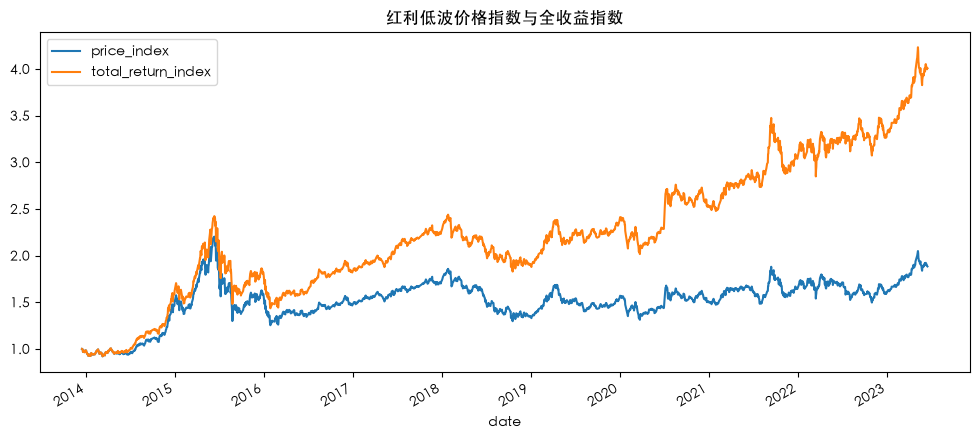

In [8]:
index_segment[["price_index", "total_return_index"]].plot(
    figsize=(12, 5),
    title="红利低波价格指数与全收益指数",
)